<!-- @q -->
## Problem 1 

Using the data in the `2019_Yellow_Taxi_Trip_Data.csv` file, calculate summary statistics for the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` columns:

In [1]:
# Your code here
import pandas as pd

taxis = pd.read_csv('./data/2019_Yellow_Taxi_Trip_Data.csv')
taxis[['fare_amount', 'tip_amount', 'tolls_amount', 'total_amount']].describe()

,fare_amount,tip_amount,tolls_amount,total_amount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,15.106313,2.634494,0.623447,22.564659
std,13.954762,3.409800,6.437507,19.209255
min,-52.000000,0.000000,-6.120000,-65.920000
25%,7.000000,0.000000,0.000000,12.375000
50%,10.000000,2.000000,0.000000,16.300000
75%,16.000000,3.250000,0.000000,22.880000
max,176.000000,43.000000,612.000000,671.800000


<!-- @q -->
## Problem 2

Isolate the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` for the longest trip by distance (`trip_distance`):

In [2]:
# Your code here
taxis.loc[
    taxis.trip_distance.idxmax(), 
    ['fare_amount', 'tip_amount', 'tolls_amount', 'total_amount']
]

fare_amount      176.0
tip_amount       18.29
tolls_amount      6.12
total_amount    201.21
Name: 8338, dtype: object

<!-- @q -->
## Problem 3 

Read in the meteorite data from the `Meteorite_Landings.csv` file, rename the `mass (g)` column to `mass`, and drop all the latitude and longitude columns. Sort the result by mass in descending order.

In [4]:
# Your code here
import pandas as pd
meteorite = pd.read_csv('./data/Meteorite_Landings.csv')
meteorite = meteorite\
    .rename(columns={'mass (g)': 'mass'})\
    .drop(columns=meteorite.columns[-3:])\
    .sort_values('mass', ascending=False)
meteorite.head()

,name,id,nametype,recclass,mass,fall,year
16392,Hoba,11890,Valid,"Iron, IVB",60000000.0,Found,01/01/1920 12:00:00 AM
5373,Cape York,5262,Valid,"Iron, IIIAB",58200000.0,Found,01/01/1818 12:00:00 AM
5365,Campo del Cielo,5247,Valid,"Iron, IAB-MG",50000000.0,Found,12/22/1575 12:00:00 AM
5370,Canyon Diablo,5257,Valid,"Iron, IAB-MG",30000000.0,Found,01/01/1891 12:00:00 AM
3455,Armanty,2335,Valid,"Iron, IIIE",28000000.0,Found,01/01/1898 12:00:00 AM


<!-- @q -->
## Problem 4

Using the meteorite data from the `Meteorite_Landings.csv` file, update the `year` column to only contain the year, convert it to a numeric data type, and create a new column indicating whether the meteorite was observed falling before 1970. Set the index to the `id` column and extract all the rows with IDs between 10,036 and 10,040 (inclusive) with `loc[]`.

**Hint 1**: Use `year.str.slice()` to grab a substring.

**Hint 2**: Make sure to sort the index before using `loc[]` to select the range.

In [5]:
# Your code here
import pandas as pd

meteorite = pd.read_csv('./data/Meteorite_Landings.csv').assign(
    year=lambda x: pd.to_numeric(x.year.str.slice(6, 10)),
    pre_1970=lambda x: (x.fall == 'Fell') & (x.year < 1970)
).set_index('id')
meteorite.sort_index().loc[10_036:10_040]

,name,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation,pre_1970
id,,,,,,,,,,
10036,Enigma,Valid,H4,94.0,Found,1967.0,31.33333,-82.31667,"(31.33333, -82.31667)",False
10037,Enon,Valid,"Iron, ungrouped",763.0,Found,1883.0,39.86667,-83.95000,"(39.86667, -83.95)",False
10038,Enshi,Valid,H5,8000.0,Fell,1974.0,30.30000,109.50000,"(30.3, 109.5)",False
10039,Ensisheim,Valid,LL6,127000.0,Fell,1491.0,47.86667,7.35000,"(47.86667, 7.35)",True


**BONUS**: There's a data entry error in the `year` column. Can you find it?

In [6]:
# Your code here
meteorite.year.describe()

count    45425.000000
mean      1991.828817
std         25.052766
min        860.000000
25%       1987.000000
50%       1998.000000
75%       2003.000000
max       2101.000000
Name: year, dtype: float64

There's a meteorite that was reportedly found in the future:

In [7]:
# Your code here
meteorite.query(f'year > {pd.Timestamp("today").year}')

,name,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation,pre_1970
id,,,,,,,,,,
57150,Northwest Africa 7701,Valid,CK6,55.0,Found,2101.0,0.0,0.0,"(0.0, 0.0)",False


_This meteorite actually was found in 2010 (more information [here](https://www.lpi.usra.edu/meteor/metbull.php?code=57150))._

<!-- @q -->
## Problem 5

Using the taxi trip data in the `2019_Yellow_Taxi_Trip_Data.csv` file, resample the data to an hourly frequency based on the dropoff time. Calculate the total `trip_distance`, `fare_amount`, `tolls_amount`, and `tip_amount`, then find the 5 hours with the most tips.

In [8]:
# Your code here
import pandas as pd
taxis = pd.read_csv(
    './data/2019_Yellow_Taxi_Trip_Data.csv',
    parse_dates=True, index_col='tpep_dropoff_datetime'
)
taxis.resample('1H')[[
    'trip_distance', 'fare_amount', 'tolls_amount', 'tip_amount'
]].sum().nlargest(5, 'tip_amount')

/tmp/ipykernel_3775/2930423689.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  taxis.resample('1H')[[


,trip_distance,fare_amount,tolls_amount,tip_amount
tpep_dropoff_datetime,,,,
2019-10-23 16:00:00,10676.95,67797.76,699.04,12228.64
2019-10-23 17:00:00,16052.83,70131.91,4044.04,12044.03
2019-10-23 18:00:00,3104.56,11565.56,1454.67,1907.64
2019-10-23 15:00:00,14.34,213.50,0.00,51.75
2019-10-23 19:00:00,98.59,268.00,24.48,25.74


<!-- @q -->
## Problem 6

Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create box plots for traveler throughput for each year in the data. Hint: Pass `kind='box'` into the `plot()` method to generate box plots.

In [12]:
# Your code here
from matplotlib import ticker
import pandas as pd

def box():
    data = pd.read_csv('./data/tsa_melted_holiday_travel.csv')
    boxplot_data = data.pivot(columns='year', values='travelers')
    axis = boxplot_data.plot(kind='box')
    axis.set_xlabel('year')
    axis.set_ylabel('travelers')
    axis.set_title('TSA Traveler Throughput')
    axis.yaxis.set_major_formatter(ticker.EngFormatter())
    return axis

<Axes: title={'center': 'TSA Traveler Throughput'}, xlabel='year', ylabel='travelers'>

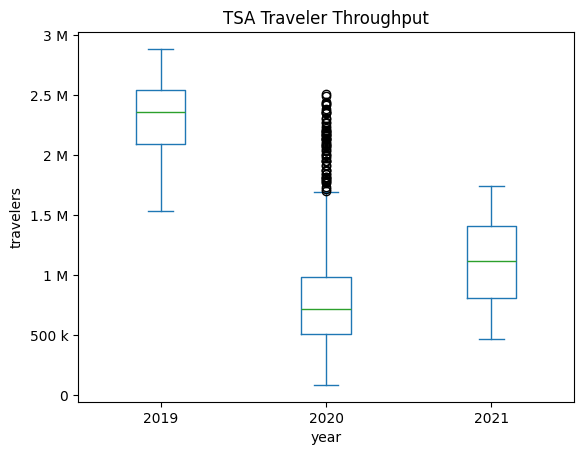

In [13]:
box()

<!-- @q -->
## Problem 7
Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create a heatmap that shows the 2019 TSA median traveler throughput by day of week and month.

In [13]:
# Your code here
import calendar
from matplotlib import ticker
import pandas as pd
import seaborn as sns

def heatmap():
    data = pd.read_csv(
        './data/tsa_melted_holiday_travel.csv',
        parse_dates=True, 
        index_col='date'
    )

    year_2019_data = data.loc['2019']
    year_2019_data = year_2019_data.assign(
        day_of_week=year_2019_data.index.dayofweek,
        month=year_2019_data.index.month
    )
    heatmap_data = year_2019_data.pivot_table(
        index='day_of_week', 
        columns='month', 
        values='travelers', 
        aggfunc='median'
    )
    axis = sns.heatmap(
        data=heatmap_data / 1e6, 
        annot=True, 
        fmt='.1f', 
        cmap='Oranges'
    )

    axis.set_xticklabels(calendar.month_abbr[1:])
    axis.set_yticklabels(calendar.day_abbr, rotation=0)
    axis.set_title('2019 TSA Median Traveler Throughput\n(in millions)')

    return axis

<Axes: title={'center': '2019 TSA Median Traveler Throughput\n(in millions)'}, xlabel='month', ylabel='day_of_week'>

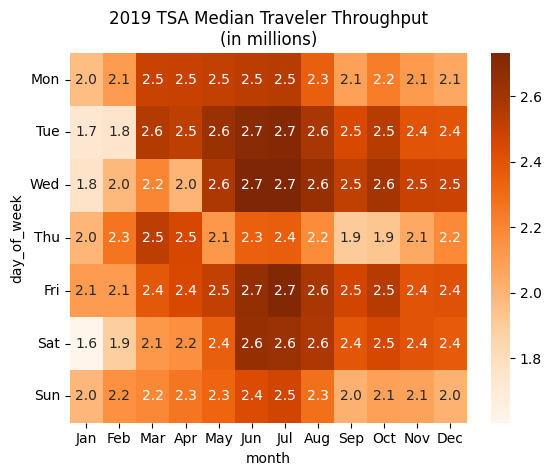

In [14]:
heatmap()